In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

os.makedirs('../outputs', exist_ok=True)

In [2]:
df = pd.read_csv('../data/processed/clean_survey.csv')

print(f"Shape: {df.shape}")
df.head()

Shape: (240, 13)


,age,year,major,gender,food,transport,entertainment,personal_care,misc,allowance,total_spend,surplus,financial_status
0,21.0,Junior,MGS,Male,20000,4000,5000,20000,2000,20000,51000,-31000,Overspending
1,20.0,Sophomore,FCSE,Female,18000,6000,0,0,1000,25000,25000,0,Balanced
2,19.0,Sophomore,FCSE,Male,15000,0,3000,0,2000,25000,20000,5000,Saving
3,20.0,Freshman,Engineering,Male,26000,0,2000,2000,2000,30000,32000,-2000,Overspending
4,21.0,Sophomore,FCSE,Female,25000,8000,5000,0,0,40000,38000,2000,Balanced


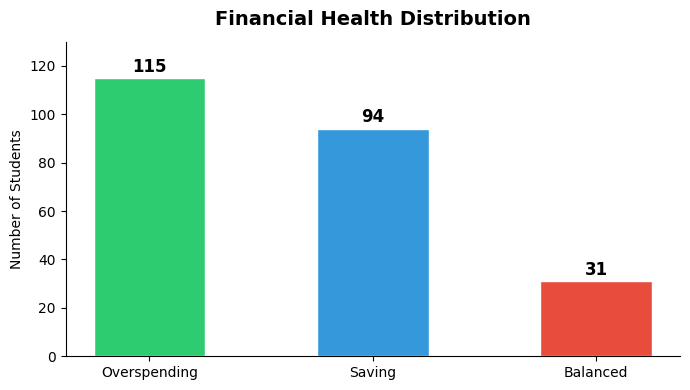

financial_status
Overspending    115
Saving           94
Balanced         31
Name: count, dtype: int64


In [3]:
status_counts = df['financial_status'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c']  # green, blue, red

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(status_counts.index, status_counts.values, color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Financial Health Distribution', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Students')
ax.set_ylim(0, status_counts.max() + 15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/financial_status_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(status_counts)

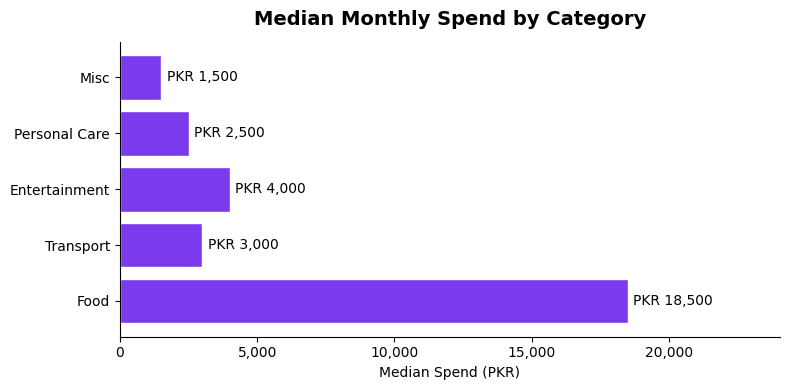

In [4]:
spending_cols = ['food', 'transport', 'entertainment', 'personal_care', 'misc']
labels = ['Food', 'Transport', 'Entertainment', 'Personal Care', 'Misc']
medians = [df[col].median() for col in spending_cols]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, medians, color='#7C3AED', edgecolor='white')

for bar, val in zip(bars, medians):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'PKR {val:,.0f}', va='center', fontsize=10)

ax.set_title('Median Monthly Spend by Category', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Median Spend (PKR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, max(medians) * 1.3)

plt.tight_layout()
plt.savefig('../outputs/spending_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

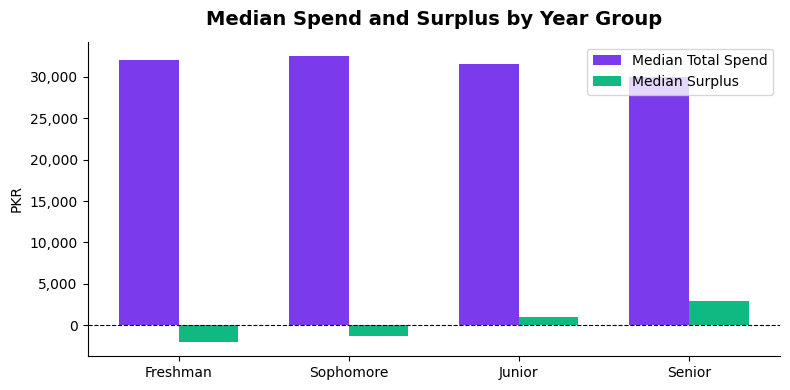

           total_spend  surplus
year                           
Freshman       32000.0  -2000.0
Sophomore      32500.0  -1250.0
Junior         31500.0   1000.0
Senior         30000.0   3000.0


In [5]:
year_order = ['Freshman', 'Sophomore', 'Junior', 'Senior']
year_stats = df.groupby('year')[['total_spend', 'surplus']].median().reindex(year_order)

x = range(len(year_order))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar([i - width/2 for i in x], year_stats['total_spend'],
               width=width, label='Median Total Spend', color='#7C3AED')
bars2 = ax.bar([i + width/2 for i in x], year_stats['surplus'],
               width=width, label='Median Surplus', color='#10B981')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(list(x))
ax.set_xticklabels(year_order)
ax.set_title('Median Spend and Surplus by Year Group', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('PKR')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/spend_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print(year_stats)

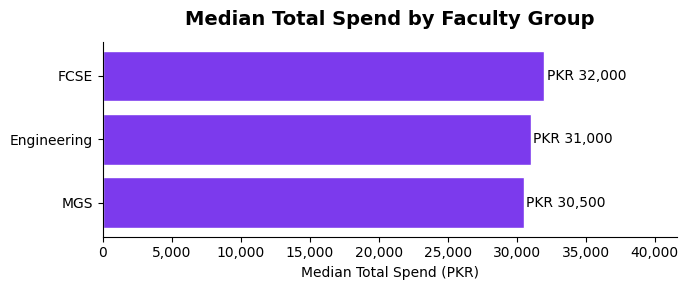

In [6]:
major_stats = df.groupby('major')['total_spend'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(major_stats.index, major_stats.values, color='#7C3AED', edgecolor='white')

for bar, val in zip(bars, major_stats.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'PKR {val:,.0f}', va='center', fontsize=10)

ax.set_title('Median Total Spend by Faculty Group', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Median Total Spend (PKR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, major_stats.max() * 1.3)

plt.tight_layout()
plt.savefig('../outputs/spend_by_faculty.png', dpi=150, bbox_inches='tight')
plt.show()

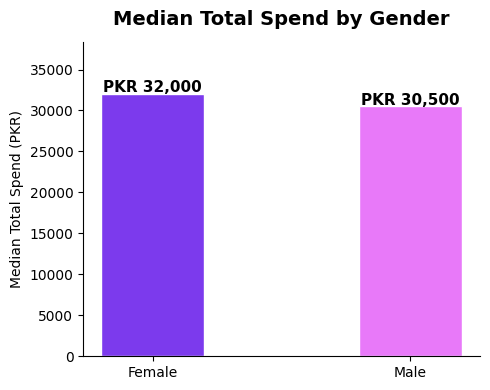

In [7]:
gender_stats = df.groupby('gender')['total_spend'].median()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(gender_stats.index, gender_stats.values,
              color=['#7C3AED', '#E879F9'], width=0.4, edgecolor='white')

for bar, val in zip(bars, gender_stats.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'PKR {val:,.0f}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Median Total Spend by Gender', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Median Total Spend (PKR)')
ax.set_ylim(0, gender_stats.max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/spend_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

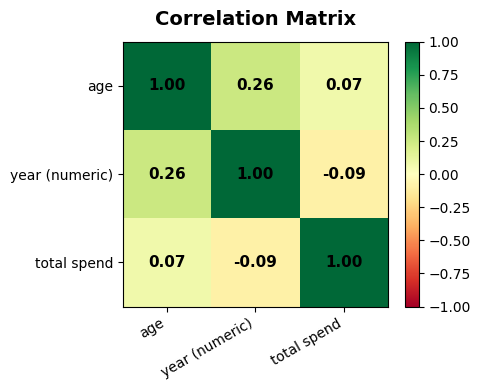

                     age  year (numeric)  total spend
age             1.000000        0.256958     0.073965
year (numeric)  0.256958        1.000000    -0.093559
total spend     0.073965       -0.093559     1.000000


In [8]:
import numpy as np

year_map = {'Freshman': 1, 'Sophomore': 2, 'Junior': 3, 'Senior': 4}
df['year_num'] = df['year'].map(year_map)

corr_df = df[['age', 'year_num', 'total_spend']].rename(
    columns={'year_num': 'year (numeric)', 'total_spend': 'total spend'}
)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=30, ha='right')
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=11, fontweight='bold')

ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean up temp column
df = df.drop(columns=['year_num'])
print(corr_matrix)

In [9]:
print("=== KEY FINDINGS ===\n")
print(f"Total students analysed: {len(df)}")
print(f"\nFinancial status breakdown:")
print(df['financial_status'].value_counts())
print(f"\nAs percentages:")
print((df['financial_status'].value_counts() / len(df) * 100).round(1))

print(f"\nMedian monthly total spend:  PKR {df['total_spend'].median():>10,.0f}")
print(f"Median monthly allowance:    PKR {df['allowance'].median():>10,.0f}")
print(f"Median monthly surplus:      PKR {df['surplus'].median():>10,.0f}")

print(f"\nBy year group:")
print(df.groupby('year')[['total_spend','allowance','surplus']].median().reindex(
    ['Freshman','Sophomore','Junior','Senior']).round(0).to_string())

=== KEY FINDINGS ===

Total students analysed: 240

Financial status breakdown:
financial_status
Overspending    115
Saving           94
Balanced         31
Name: count, dtype: int64

As percentages:
financial_status
Overspending    47.9
Saving          39.2
Balanced        12.9
Name: count, dtype: float64

Median monthly total spend:  PKR     32,000
Median monthly allowance:    PKR     31,000
Median monthly surplus:      PKR     -1,000

By year group:
           total_spend  allowance  surplus
year                                      
Freshman       32000.0    31000.0  -2000.0
Sophomore      32500.0    31500.0  -1250.0
Junior         31500.0    32500.0   1000.0
Senior         30000.0    35000.0   3000.0
